<a href="https://colab.research.google.com/github/ArshanBhanage/258-Assignment_3/blob/main/colab_a_numpy_scratch_3layer_einsum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab (a) — NumPy-from-scratch 3-Layer Deep Neural Network (Nonlinear Regression)

**Goal:** Implement a **3-layer** neural network (parameters: `W1/W2/W3`, `b1/b2/b3`) for **nonlinear regression** using **manual backpropagation** (chain rule).

✅ Requirements covered in this notebook:
- Synthetic data from a **3-variable nonlinear equation** `(x1, x2, x3) -> y`
- **3-layer** neural network: `3 → H1 → H2 → 1`
- Proper **nonlinear activations**
- **Manual backprop** (no autograd)
- Uses **`tf.einsum`** for linear algebra instead of matrix multiply (`@`/`matmul`)
- Training curve (loss vs epochs) + final output evaluation
- **“4D plot”** approach: reduce 3D inputs to 3D (PCA) and use **color = y** as the 4th dimension

> **Note:** We use TensorFlow *only* for `tf.einsum` to satisfy the einsum requirement. All learning (gradients, updates) is still fully manual.


## 0. Setup

In [10]:
# Colab usually has these already:
# !pip -q install numpy matplotlib scikit-learn tensorflow

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("NumPy:", np.__version__)
print("TensorFlow:", tf.__version__)


NumPy: 2.0.2
TensorFlow: 2.19.0


## 1. Generate synthetic nonlinear regression data (3 variables)

In [11]:
def nonlinear_equation(x1, x2, x3):
    """Nonlinear 3-variable target function."""
    return (
        2.0 * np.sin(x1)
        + 0.5 * (x2 ** 2)
        - 3.0 * np.exp(-x3)
        + 0.3 * x1 * x2
        - 0.2 * x2 * x3
    )

# Generate features
N = 6000
x1 = np.random.uniform(-3.0, 3.0, size=(N, 1))
x2 = np.random.uniform(-2.0, 2.0, size=(N, 1))
x3 = np.random.uniform(0.0, 4.0, size=(N, 1))

X = np.concatenate([x1, x2, x3], axis=1)  # (N, 3)

# Generate labels with noise
noise = np.random.normal(loc=0.0, scale=0.2, size=(N, 1))
y = nonlinear_equation(x1, x2, x3).reshape(-1, 1) + noise  # (N, 1)

print("X shape:", X.shape, "y shape:", y.shape)
print("y mean/std:", float(y.mean()), float(y.std()))


X shape: (6000, 3) y shape: (6000, 1)
y mean/std: -0.06992541188154212 1.9272837657625705


## 2. Quick visualization ("4D" plot via PCA + color = y)

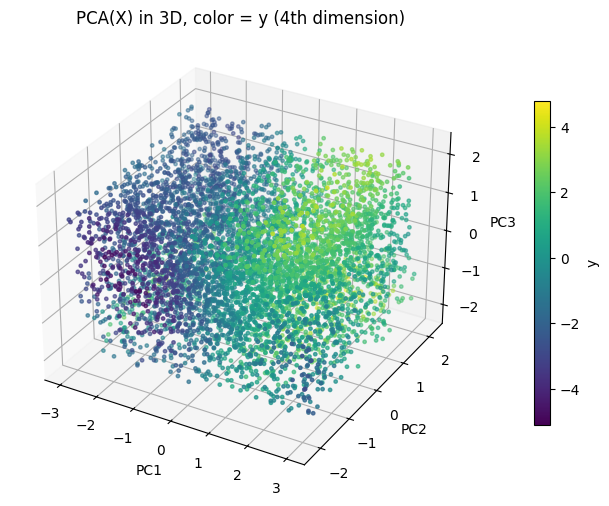

Explained variance ratios: [0.53238454 0.23517503 0.23244043]


In [12]:
# Reduce 3D X to 3D via PCA for a 3D scatter.
# Use color to represent y => visually a "4D" idea: (PC1, PC2, PC3, color=y)
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=y[:, 0], s=6)
ax.set_title("PCA(X) in 3D, color = y (4th dimension)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.colorbar(sc, ax=ax, pad=0.1, shrink=0.7, label="y")
plt.show()

print("Explained variance ratios:", pca.explained_variance_ratio_)


## 3. Train/Val/Test split + standardization

In [13]:
# Split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# Standardize features
x_scaler = StandardScaler()
X_train_s = x_scaler.fit_transform(X_train)
X_val_s   = x_scaler.transform(X_val)
X_test_s  = x_scaler.transform(X_test)

# Standardize target (helps optimization)
y_scaler = StandardScaler()
y_train_s = y_scaler.fit_transform(y_train)
y_val_s   = y_scaler.transform(y_val)
y_test_s  = y_scaler.transform(y_test)

print("Train:", X_train_s.shape, y_train_s.shape)
print("Val  :", X_val_s.shape, y_val_s.shape)
print("Test :", X_test_s.shape, y_test_s.shape)


Train: (4200, 3) (4200, 1)
Val  : (900, 3) (900, 1)
Test : (900, 3) (900, 1)


## 4. Core math utilities (activations + derivatives)

In [14]:
def tanh(x):
    return np.tanh(x)

def dtanh(x):
    t = np.tanh(x)
    return 1.0 - t * t

def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

def mse_grad(y_true, y_pred):
    # d/dy_pred mean((y_pred - y_true)^2) = 2*(y_pred - y_true)/N
    n = y_true.shape[0]
    return (2.0 / n) * (y_pred - y_true)


## 5. 3-layer neural network (manual forward + manual backprop)

Architecture:
- Layer1: `X -> H1` with `tanh`
- Layer2: `H1 -> H2` with `tanh`
- Layer3: `H2 -> y_hat` (linear output for regression)

**Important:** Linear transforms use `tf.einsum("bi,io->bo")` instead of matrix multiply.


In [15]:
class ThreeLayerNN:
    """3-layer MLP: 3 -> hidden1 -> hidden2 -> 1. Manual gradients + SGD."""

    def __init__(self, d_in=3, d_h1=64, d_h2=32, d_out=1, seed=42):
        rng = np.random.default_rng(seed)

        # Xavier/Glorot-like initialization
        def xavier(in_dim, out_dim):
            limit = np.sqrt(6.0 / (in_dim + out_dim))
            return rng.uniform(-limit, limit, size=(in_dim, out_dim)).astype(np.float32)

        self.W1 = xavier(d_in, d_h1)
        self.b1 = np.zeros((d_h1,), dtype=np.float32)

        self.W2 = xavier(d_h1, d_h2)
        self.b2 = np.zeros((d_h2,), dtype=np.float32)

        self.W3 = xavier(d_h2, d_out)
        self.b3 = np.zeros((d_out,), dtype=np.float32)

    @staticmethod
    def _einsum_mm(A_np, B_np):
        """(batch,in) x (in,out) -> (batch,out) via tf.einsum"""
        A = tf.convert_to_tensor(A_np)
        B = tf.convert_to_tensor(B_np)
        out = tf.einsum('bi,io->bo', A, B)
        return out.numpy()

    def forward(self, X):
        # z1 = X W1 + b1
        z1 = self._einsum_mm(X, self.W1) + self.b1
        a1 = tanh(z1)

        # z2 = a1 W2 + b2
        z2 = self._einsum_mm(a1, self.W2) + self.b2
        a2 = tanh(z2)

        # z3 = a2 W3 + b3 (linear output)
        z3 = self._einsum_mm(a2, self.W3) + self.b3
        y_hat = z3

        cache = {'X': X, 'z1': z1, 'a1': a1, 'z2': z2, 'a2': a2, 'y_hat': y_hat}
        return y_hat, cache

    def backward(self, y_true, cache):
        X = cache['X']
        z1, a1 = cache['z1'], cache['a1']
        z2, a2 = cache['z2'], cache['a2']
        y_hat = cache['y_hat']

        # dL/dy_hat
        d_yhat = mse_grad(y_true, y_hat).astype(np.float32)  # (batch,1)

        # Layer 3: y_hat = a2 W3 + b3
        dW3 = (a2.T @ d_yhat).astype(np.float32)            # (h2,1)
        db3 = np.sum(d_yhat, axis=0).astype(np.float32)     # (1,)

        # Backprop to a2
        d_a2 = (d_yhat @ self.W3.T).astype(np.float32)       # (batch,h2)

        # a2 = tanh(z2)
        d_z2 = d_a2 * dtanh(z2).astype(np.float32)           # (batch,h2)

        # Layer 2: z2 = a1 W2 + b2
        dW2 = (a1.T @ d_z2).astype(np.float32)               # (h1,h2)
        db2 = np.sum(d_z2, axis=0).astype(np.float32)        # (h2,)

        # Backprop to a1
        d_a1 = (d_z2 @ self.W2.T).astype(np.float32)         # (batch,h1)

        # a1 = tanh(z1)
        d_z1 = d_a1 * dtanh(z1).astype(np.float32)           # (batch,h1)

        # Layer 1: z1 = X W1 + b1
        dW1 = (X.T @ d_z1).astype(np.float32)                # (3,h1)
        db1 = np.sum(d_z1, axis=0).astype(np.float32)        # (h1,)

        return {'dW1': dW1, 'db1': db1, 'dW2': dW2, 'db2': db2, 'dW3': dW3, 'db3': db3}

    def step(self, grads, lr=1e-3):
        self.W1 -= lr * grads['dW1']
        self.b1 -= lr * grads['db1']
        self.W2 -= lr * grads['dW2']
        self.b2 -= lr * grads['db2']
        self.W3 -= lr * grads['dW3']
        self.b3 -= lr * grads['db3']

    def predict(self, X):
        y_hat, _ = self.forward(X)
        return y_hat


## 6. Training loop (mini-batch SGD) + loss curves

Epoch    1 | train MSE: 1.263740 | val MSE: 1.112375
Epoch   25 | train MSE: 0.407791 | val MSE: 0.444882
Epoch   50 | train MSE: 0.396660 | val MSE: 0.434233
Epoch   75 | train MSE: 0.383961 | val MSE: 0.420317
Epoch  100 | train MSE: 0.365487 | val MSE: 0.401732
Epoch  125 | train MSE: 0.341990 | val MSE: 0.377122
Epoch  150 | train MSE: 0.312554 | val MSE: 0.346067
Epoch  175 | train MSE: 0.276963 | val MSE: 0.309534
Epoch  200 | train MSE: 0.239144 | val MSE: 0.269944
Epoch  225 | train MSE: 0.201377 | val MSE: 0.230536
Epoch  250 | train MSE: 0.167346 | val MSE: 0.194018


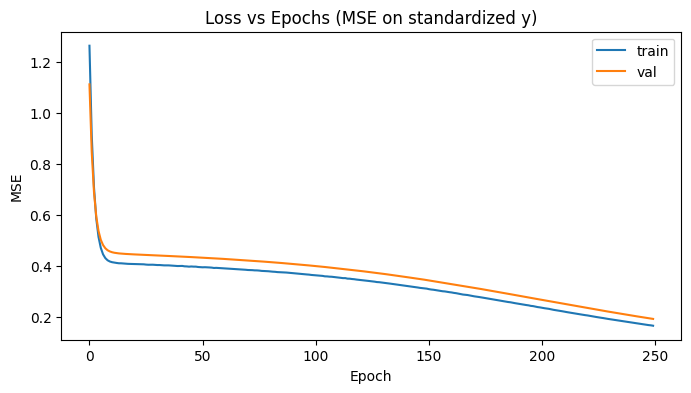

In [16]:
def iterate_minibatches(X, y, batch_size=128, shuffle=True, seed=42):
    n = X.shape[0]
    idx = np.arange(n)
    if shuffle:
        rng = np.random.default_rng(seed)
        rng.shuffle(idx)
    for start in range(0, n, batch_size):
        batch_idx = idx[start:start + batch_size]
        yield X[batch_idx], y[batch_idx]

# Hyperparameters
hidden1 = 64
hidden2 = 32
lr = 1e-3
epochs = 250
batch_size = 128

model = ThreeLayerNN(d_in=3, d_h1=hidden1, d_h2=hidden2, d_out=1, seed=42)

train_losses, val_losses = [], []

X_train_f = X_train_s.astype(np.float32)
y_train_f = y_train_s.astype(np.float32)
X_val_f = X_val_s.astype(np.float32)
y_val_f = y_val_s.astype(np.float32)

for epoch in range(1, epochs + 1):
    # ---- Train (mini-batches) ----
    epoch_train_loss = 0.0
    steps = 0

    for Xb, yb in iterate_minibatches(X_train_f, y_train_f, batch_size=batch_size, shuffle=True, seed=42 + epoch):
        yhat, cache = model.forward(Xb)
        grads = model.backward(yb, cache)
        model.step(grads, lr=lr)
        epoch_train_loss += mse(yb, yhat)
        steps += 1

    epoch_train_loss /= max(steps, 1)

    # ---- Validate (full batch) ----
    yval_hat = model.predict(X_val_f)
    epoch_val_loss = mse(y_val_f, yval_hat)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    if epoch % 25 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d} | train MSE: {epoch_train_loss:.6f} | val MSE: {epoch_val_loss:.6f}")

# Plot loss curves
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.title('Loss vs Epochs (MSE on standardized y)')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()


## 7. Final evaluation (test set) + plots (true vs predicted)

Final TEST MSE (original y scale): 0.6064360065752445


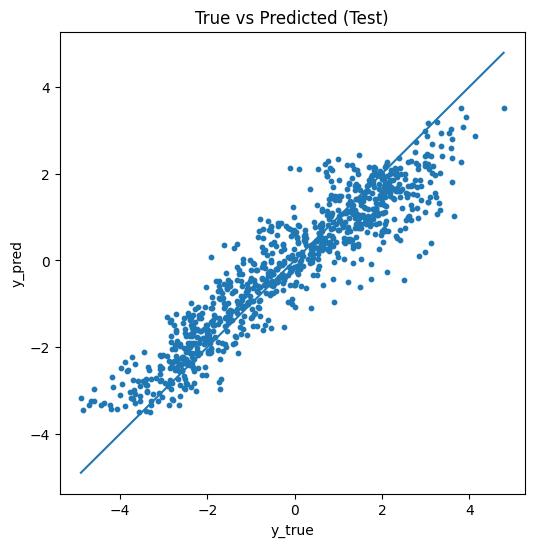

Example 0: y_true= 0.509 | y_pred= 0.290
Example 1: y_true=-2.526 | y_pred=-2.302
Example 2: y_true= 1.109 | y_pred= 0.825
Example 3: y_true=-0.009 | y_pred= 0.254
Example 4: y_true=-3.119 | y_pred=-3.245
Example 5: y_true=-2.076 | y_pred=-1.588
Example 6: y_true= 2.823 | y_pred= 2.100
Example 7: y_true=-2.021 | y_pred=-0.614
Example 8: y_true= 2.596 | y_pred= 0.995
Example 9: y_true=-1.838 | y_pred=-1.256


In [17]:
# Predict on standardized scale
X_test_f = X_test_s.astype(np.float32)
y_test_f = y_test_s.astype(np.float32)

y_test_hat_s = model.predict(X_test_f)

# Inverse-transform to original y scale
y_test_hat = y_scaler.inverse_transform(y_test_hat_s)
y_test_true = y_test

test_mse = mse(y_test_true, y_test_hat)
print('Final TEST MSE (original y scale):', test_mse)

# Scatter: true vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test_true[:, 0], y_test_hat[:, 0], s=10)
plt.title('True vs Predicted (Test)')
plt.xlabel('y_true')
plt.ylabel('y_pred')
minv = min(y_test_true.min(), y_test_hat.min())
maxv = max(y_test_true.max(), y_test_hat.max())
plt.plot([minv, maxv], [minv, maxv])  # diagonal reference
plt.show()

# Show a few examples
for i in range(10):
    print(f"Example {i}: y_true={y_test_true[i,0]: .3f} | y_pred={y_test_hat[i,0]: .3f}")


## 8. Save weights to a `.npz` file (optional but nice for grading)

In [18]:
save_path = 'numpy_scratch_3layer_weights.npz'
np.savez(
    save_path,
    W1=model.W1, b1=model.b1,
    W2=model.W2, b2=model.b2,
    W3=model.W3, b3=model.b3,
    x_mean=x_scaler.mean_, x_scale=x_scaler.scale_,
    y_mean=y_scaler.mean_, y_scale=y_scaler.scale_,
)
print('Saved:', save_path)


Saved: numpy_scratch_3layer_weights.npz


## 9. What to say in your video (quick script)

1. **GitHub check-in**: show repo, files, commits.
2. Open this notebook and go section-by-section:
   - **Data gen**: explain the 3-variable nonlinear equation and noise.
   - **4D plot**: explain PCA to 3D and color as the 4th dimension.
   - **Model**: show `W1/W2/W3` shapes; explain `3 → 64 → 32 → 1`.
   - **Forward**: point out `tf.einsum('bi,io->bo')` replacing matrix multiply.
   - **Backprop**: chain rule from MSE → layer3 → layer2 → layer1.
   - **Training loop**: mini-batches, LR, epochs, printed loss.
   - **Results**: loss curve and true-vs-predicted plot + test MSE.
3. End by showing final output cells and the repo link in README.
